<a href="https://colab.research.google.com/github/Frabat/CS_6795_Appraisal_Notebook/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import io
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')
path = '/content/gdrive/My Drive/CogSci_Reddit_2025_Dump/mlx_annotated_results.csv'
df = pd.read_csv(path)
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,Unnamed: 0,subreddit,author_hash,id,link_id,parent_id,score,body,created_utc,anchor_url,neutral_context,agency,goal_congruence,certainty
0,0,democrats,1440ea1b556b,c8iil1d,t3_18vdpw,t3_18vdpw,3,I personally don't understand why people get s...,1.361380e+09,http://antiwar.com/blog/2013/02/19/nancy-pelos...,This is more of a distinction than you might t...,0.2,-0.8,0.9
1,1,politics,9ebfe9046c32,cpir1po,t3_2zgkog,t3_2zgkog,60,"The ""most transparent administration in US his...",1.426687e+09,http://bigstory.ap.org/article/ab029d7c6251493...,"US sets new record for denying, censoring gove...",0.0,-1.0,0.8
2,2,politics,1c31bc3e2a7b,cpirvpk,t3_2zgkog,t1_cpirtl8,37,Yet he goes after whistleblowers at an unprece...,1.426689e+09,http://bigstory.ap.org/article/ab029d7c6251493...,"US sets new record for denying, censoring gove...",-0.5,-1.0,0.9
3,3,politics,dd744ef7d7a9,cpixzdg,t3_2zgkog,t3_2zgkog,33,"""The only people who don't want to disclose th...",1.426699e+09,http://bigstory.ap.org/article/ab029d7c6251493...,"US sets new record for denying, censoring gove...",-0.5,-1.0,1.0
4,4,politics,cbde1724b93a,cpistom,t3_2zgkog,t1_cpirtl8,23,"Hey, if you are sure you censored everything y...",1.426691e+09,http://bigstory.ap.org/article/ab029d7c6251493...,"US sets new record for denying, censoring gove...",0.0,-1.0,0.8


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Descriptive Statistics: Mean, Median, and Standard Deviation
print("Descriptive Statistics by Subreddit:")
summary_stats = df.groupby('subreddit')[['agency', 'goal_congruence', 'certainty']].agg(['mean', 'median', 'std'])
display(summary_stats)


Descriptive Statistics by Subreddit:


agency                  goal_congruence                   \
                   mean median       std            mean median       std   
subreddit                                                                   
conservatives  0.129184    0.0  0.319737       -0.632711   -0.8  0.459094   
democrats      0.095088    0.0  0.338147       -0.663818   -0.8  0.462488   
politics       0.073668    0.0  0.330863       -0.687908   -0.8  0.447190   

              certainty                   
                   mean median       std  
subreddit                                 
conservatives  0.769577    0.8  0.256924  
democrats      0.789477    0.9  0.242569  
politics       0.800986    0.9  0.233006

/tmp/ipykernel_12388/2115789267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_12388/2115789267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_12388/2115789267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


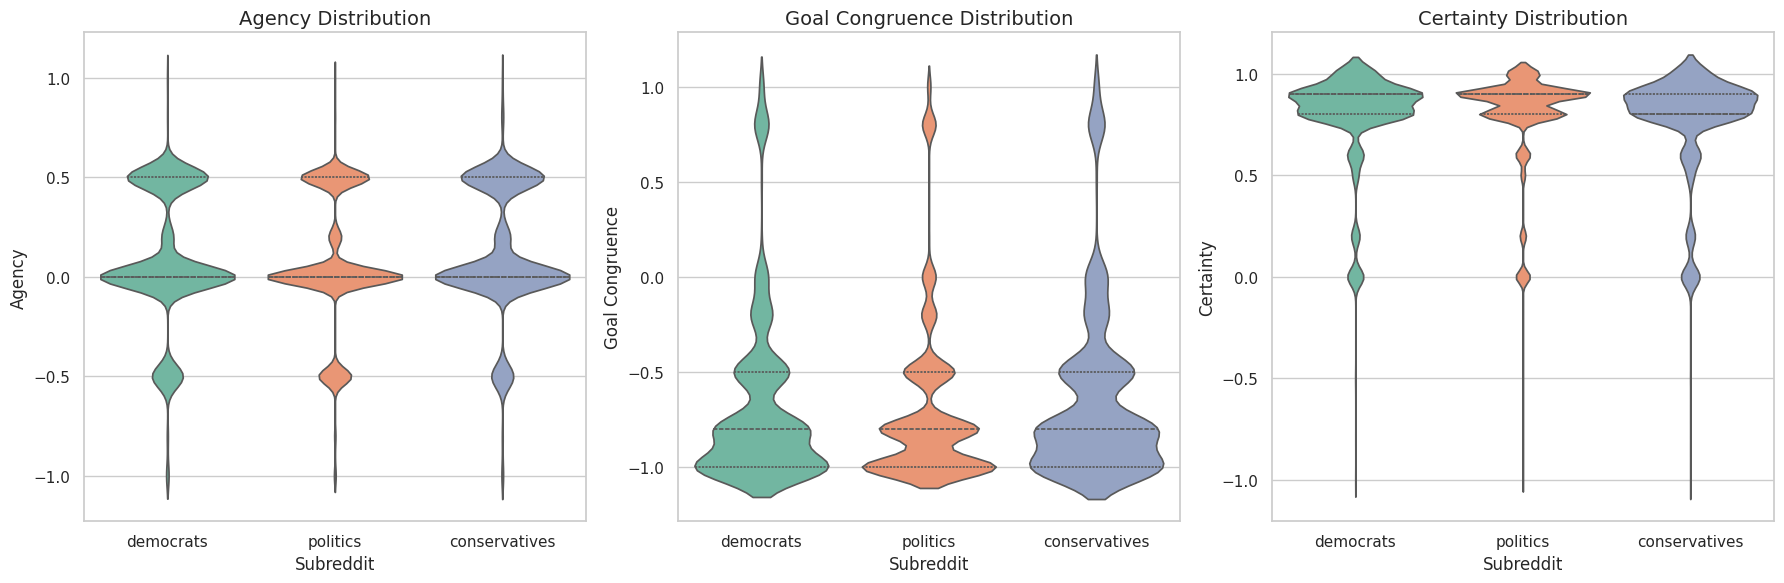

In [6]:
# Visualizations: 1x3 subplot using Violin Plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dimensions = ['agency', 'goal_congruence', 'certainty']
titles = ['Agency Distribution', 'Goal Congruence Distribution', 'Certainty Distribution']
palette = "Set2" # Distinct color palette

for i, dim in enumerate(dimensions):
    sns.violinplot(
        data=df,
        x='subreddit',
        y=dim,
        ax=axes[i],
        palette=palette,
        inner="quartile" # Show quartiles inside the violin
    )
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel('Subreddit', fontsize=12)
    axes[i].set_ylabel(dim.replace('_', ' ').title(), fontsize=12)

plt.tight_layout()
plt.show()


In [7]:
# Statistical Significance: Kruskal-Wallis H-test (non-parametric ANOVA)
print("Kruskal-Wallis H-test Results:")

for dim in dimensions:
    # Extract values for each group, dropping any NaNs
    groups = [group[dim].dropna().values for name, group in df.groupby('subreddit')]

    # Perform Kruskal-Wallis test
    stat, p_val = stats.kruskal(*groups)

    print(f"\nDimension: {dim.replace('_', ' ').title()}")
    print(f"H-statistic: {stat:.4f}")
    print(f"P-value: {p_val:.4e}")

    if p_val < 0.05:
        print("Result: Statistically significant difference between subreddits.")
    else:
        print("Result: No statistically significant difference between subreddits.")


Kruskal-Wallis H-test Results:

Dimension: Agency
H-statistic: 136.4435
P-value: 2.3533e-30
Result: Statistically significant difference between subreddits.

Dimension: Goal Congruence
H-statistic: 139.8890
P-value: 4.2023e-31
Result: Statistically significant difference between subreddits.

Dimension: Certainty
H-statistic: 147.6470
P-value: 8.6869e-33
Result: Statistically significant difference between subreddits.


In [8]:
# Step 1 & 2: Filter for Shared Content & Aggregation

# Find URLs that appear in at least two different subreddits
url_sub_counts = df.groupby('anchor_url')['subreddit'].nunique()
shared_urls = url_sub_counts[url_sub_counts >= 2].index

# Create a subset of data with only shared URLs
shared_df = df[df['anchor_url'].isin(shared_urls)]

# Calculate the mean scores for agency, goal_congruence, and certainty
agg_df = shared_df.groupby(['anchor_url', 'subreddit'])[['agency', 'goal_congruence', 'certainty']].mean().reset_index()

print(f"Found {len(shared_urls)} URLs shared across multiple subreddits.")
display(agg_df.head())


Found 825 URLs shared across multiple subreddits.


,anchor_url,subreddit,agency,goal_congruence,certainty
0,http://bigstory.ap.org/article/ab029d7c6251493...,conservatives,-0.166667,-1.000000,0.533333
1,http://bigstory.ap.org/article/ab029d7c6251493...,politics,-0.059375,-0.887500,0.800000
2,http://blogs.seattletimes.com/politicsnorthwes...,conservatives,0.133333,-0.866667,0.800000
3,http://blogs.seattletimes.com/politicsnorthwes...,democrats,-0.166667,-0.766667,0.900000
4,http://blogs.seattletimes.com/politicsnorthwes...,politics,0.175000,-0.850000,0.850000


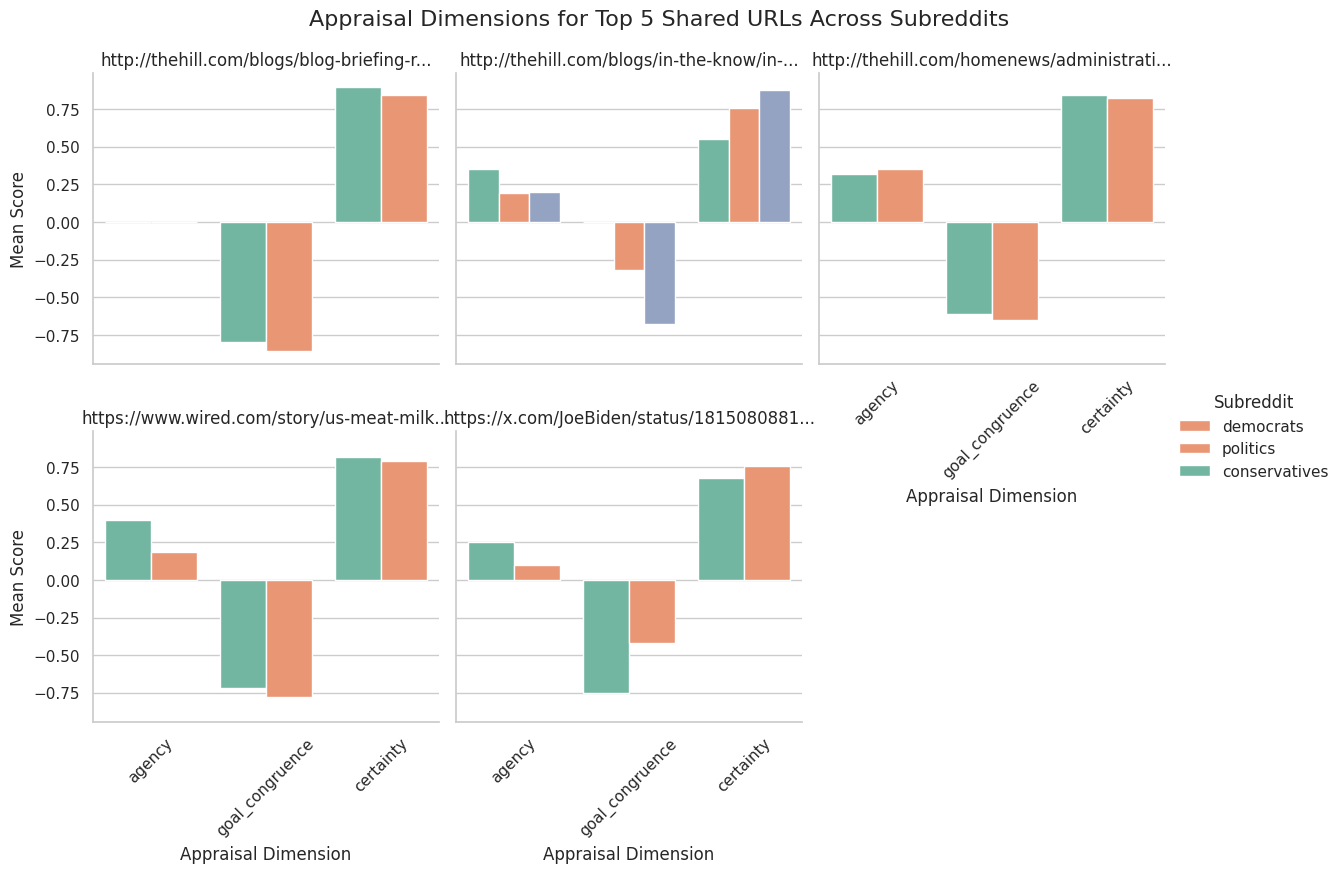

In [9]:
# Step 3: Visualization for Top URLs
import seaborn as sns
import matplotlib.pyplot as plt

# Identify the top 5 shared URLs with the most total comments across subreddits
top_urls = shared_df['anchor_url'].value_counts().head(5).index
plot_df = agg_df[agg_df['anchor_url'].isin(top_urls)].copy()

# Shorten URLs for cleaner plot titles
plot_df['url_short'] = plot_df['anchor_url'].apply(lambda x: x[:40] + '...' if isinstance(x, str) and len(x) > 40 else x)

# Melt the dataframe for easier plotting with seaborn
melted_plot_df = plot_df.melt(id_vars=['url_short', 'subreddit'],
                              value_vars=['agency', 'goal_congruence', 'certainty'],
                              var_name='dimension', value_name='score')

# Create a FacetGrid with grouped bar charts
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(melted_plot_df, col="url_short", col_wrap=3, height=4, sharey=True)
g.map_dataframe(sns.barplot, x="dimension", y="score", hue="subreddit", palette="Set2")
g.add_legend(title="Subreddit")
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Appraisal Dimension", "Mean Score")

# Rotate x-axis labels for readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Appraisal Dimensions for Top 5 Shared URLs Across Subreddits', fontsize=16)
plt.show()


In [10]:
# Step 4 & 5: Divergence Metric & Output
import numpy as np
from scipy.spatial import distance

# Pivot the aggregated dataframe to easily access conservative and democrat vectors per URL
pivot_df = agg_df.pivot(index='anchor_url', columns='subreddit', values=['agency', 'goal_congruence', 'certainty'])

gaps = []
# Iterate through each shared URL
for url in pivot_df.index:
    try:
        # Extract the appraisal vectors for conservatives and democrats
        cons_vec = pivot_df.loc[url, (slice(None), 'conservatives')].values
        dems_vec = pivot_df.loc[url, (slice(None), 'democrats')].values

        # Check if both vectors exist and contain no NaNs
        if not np.isnan(cons_vec).any() and not np.isnan(dems_vec).any():
            dist = distance.euclidean(cons_vec, dems_vec)
            gaps.append({
                'anchor_url': url,
                'appraisal_gap': dist,
                'cons_agency': cons_vec[0], 'cons_goal_cong': cons_vec[1], 'cons_certainty': cons_vec[2],
                'dems_agency': dems_vec[0], 'dems_goal_cong': dems_vec[1], 'dems_certainty': dems_vec[2]
            })
    except KeyError:
        # Skip if one of the subreddits is missing for this URL
        continue

gap_df = pd.DataFrame(gaps)

if not gap_df.empty:
    # Sort by the highest Appraisal Gap
    gap_df = gap_df.sort_values(by='appraisal_gap', ascending=False).reset_index(drop=True)
    print("Top URLs with the highest Appraisal Gap (Divergence) between Conservatives and Democrats:")
    display(gap_df.head(10))
else:
    print("No URLs were shared strictly between both 'conservatives' and 'democrats' to calculate the gap.")


Top URLs with the highest Appraisal Gap (Divergence) between Conservatives and Democrats:


,anchor_url,appraisal_gap,cons_agency,cons_goal_cong,cons_certainty,dems_agency,dems_goal_cong,dems_certainty
0,https://thefriendofthepeopleblog.blogspot.com/...,1.868154,0.000000,0.8,1.000000,-0.500,-1.000,1.00
1,https://twitter.com/JenGriffinFNC/status/13019...,1.868154,0.500000,0.8,0.900000,0.000,-1.000,0.90
2,https://academictimes.com/vulnerable-democrati...,1.435270,0.000000,0.0,0.000000,-0.500,-1.000,0.90
3,https://youtu.be/3pPSBy3skwg,1.296630,0.000000,-1.0,0.800000,0.375,0.225,0.60
4,https://www.sfchronicle.com/politics/article/P...,1.280625,0.000000,-0.8,1.000000,0.000,0.000,0.00
5,https://thehill.com/homenews/campaign/521151-b...,1.171537,0.250000,-0.1,0.800000,-0.500,-1.000,0.80
6,https://finflam.com/archives/14338,1.107926,0.000000,-1.0,0.800000,-0.250,-0.750,-0.25
7,https://www.washingtonpost.com/opinions/ted-cr...,1.078612,0.133333,-1.0,0.800000,0.375,0.050,0.75
8,https://www.nytimes.com/2024/11/14/world/middl...,1.077033,0.000000,0.0,0.600000,0.000,-1.000,1.00
9,https://www.whitehouse.gov/trump-administratio...,1.053038,0.233333,0.0,0.766667,0.000,-1.000,1.00


In [11]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
import plotly.graph_objects as go

# 1 & 2: Vectorization & Subreddit Centroids
# Filter for shared URLs
url_counts = df.groupby('anchor_url')['subreddit'].nunique()
shared_urls = url_counts[url_counts >= 2].index
shared_df = df[df['anchor_url'].isin(shared_urls)]

# Calculate mean vector (centroid) for each URL and subreddit
centroids_df = shared_df.groupby(['anchor_url', 'subreddit'])[['agency', 'goal_congruence', 'certainty']].mean().reset_index()

# Pivot to get subreddits as columns for easy access
pivot_centroids = centroids_df.pivot(index='anchor_url', columns='subreddit', values=['agency', 'goal_congruence', 'certainty'])

# 3, 4 & 5: Distance Calculation, Global Index, & Politics Baseline
gaps = []
pol_cons_dists = []
pol_dems_dists = []

for url in pivot_centroids.index:
    try:
        # Extract appraisal vectors
        cons_vec = pivot_centroids.loc[url, (slice(None), 'conservatives')].values
        dems_vec = pivot_centroids.loc[url, (slice(None), 'democrats')].values
        pol_vec = pivot_centroids.loc[url, (slice(None), 'politics')].values

        # Euclidean distance for Polarization Gap
        if not np.isnan(cons_vec).any() and not np.isnan(dems_vec).any():
            gaps.append(distance.euclidean(cons_vec, dems_vec))

        # Euclidean distance for Politics Baseline
        if not np.isnan(pol_vec).any():
            if not np.isnan(cons_vec).any():
                pol_cons_dists.append(distance.euclidean(pol_vec, cons_vec))
            if not np.isnan(dems_vec).any():
                pol_dems_dists.append(distance.euclidean(pol_vec, dems_vec))
    except KeyError:
        continue

global_index = np.mean(gaps) if gaps else 0
mean_pol_cons = np.mean(pol_cons_dists) if pol_cons_dists else 0
mean_pol_dems = np.mean(pol_dems_dists) if pol_dems_dists else 0

print(f"Global Polarization Index (Mean Appraisal Gap): {global_index:.4f}")
print(f"Mean Distance: Politics to Conservatives: {mean_pol_cons:.4f}")
print(f"Mean Distance: Politics to Democrats: {mean_pol_dems:.4f}")

if mean_pol_cons < mean_pol_dems:
    print("\nResult: r/politics aligns more closely with conservatives on average for shared URLs.")
elif mean_pol_dems < mean_pol_cons:
    print("\nResult: r/politics aligns more closely with democrats on average for shared URLs.")
else:
    print("\nResult: r/politics is equally distant from both (or insufficient data).")


Global Polarization Index (Mean Appraisal Gap): 0.4371
Mean Distance: Politics to Conservatives: 0.4057
Mean Distance: Politics to Democrats: 0.3648

Result: r/politics aligns more closely with democrats on average for shared URLs.


In [12]:
# 6. Visualization: 3D Scatter Plot for top 10 shared URLs
# Get top 10 URLs by total comment count in the shared dataframe
top10_urls = shared_df['anchor_url'].value_counts().head(10).index
top10_centroids = centroids_df[centroids_df['anchor_url'].isin(top10_urls)]

fig = go.Figure()

# Define colors for subreddits
color_map = {'conservatives': 'red', 'democrats': 'blue', 'politics': 'green'}

# Add Scatter3d traces for each subreddit's centroids
for sub in color_map.keys():
    sub_data = top10_centroids[top10_centroids['subreddit'] == sub]
    fig.add_trace(go.Scatter3d(
        x=sub_data['agency'],
        y=sub_data['goal_congruence'],
        z=sub_data['certainty'],
        mode='markers',
        name=sub,
        marker=dict(size=6, color=color_map[sub], opacity=0.8),
        text=sub_data['anchor_url'].apply(lambda x: str(x)[:50] + '...'),
        hovertemplate='<b>%{text}</b><br>Agency: %{x:.2f}<br>Goal Congruence: %{y:.2f}<br>Certainty: %{z:.2f}'
    ))

# Add lines connecting conservatives and democrats for the same URL (the 'Gap')
for url in top10_urls:
    url_data = top10_centroids[top10_centroids['anchor_url'] == url]
    cons_data = url_data[url_data['subreddit'] == 'conservatives']
    dems_data = url_data[url_data['subreddit'] == 'democrats']

    if not cons_data.empty and not dems_data.empty:
        fig.add_trace(go.Scatter3d(
            x=[cons_data['agency'].values[0], dems_data['agency'].values[0]],
            y=[cons_data['goal_congruence'].values[0], dems_data['goal_congruence'].values[0]],
            z=[cons_data['certainty'].values[0], dems_data['certainty'].values[0]],
            mode='lines',
            line=dict(color='gray', width=2, dash='dot'),
            showlegend=False,
            hoverinfo='skip'
        ))

fig.update_layout(
    title='Appraisal-Based Polarization: Top 10 Shared URLs',
    scene=dict(
        xaxis_title='Agency',
        yaxis_title='Goal Congruence',
        zaxis_title='Certainty'
    ),
    legend_title='Subreddit',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


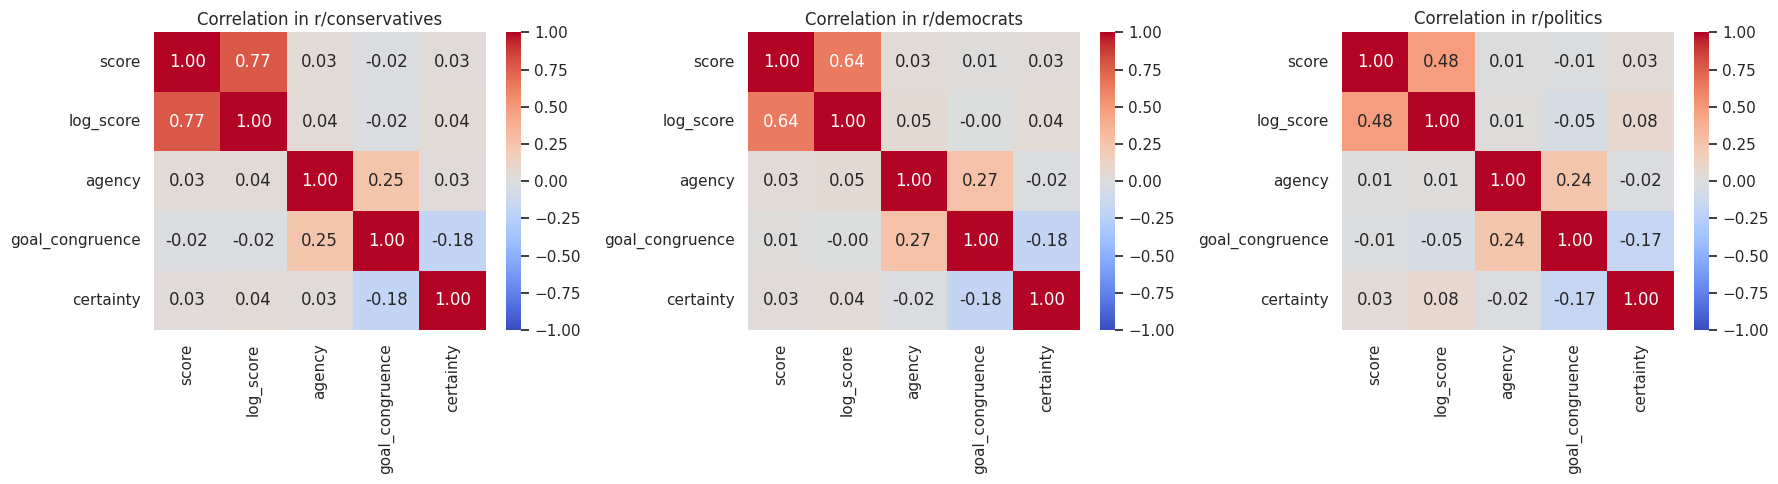

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Data Preprocessing
# Create log_score to handle the skewness of Reddit scores
df['log_score'] = np.log1p(df['score'].clip(lower=0)) # clip at 0 to avoid negative logs if any score < 0

# Step 2: Correlation Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
subreddits = ['conservatives', 'democrats', 'politics']
cols_to_corr = ['score', 'log_score', 'agency', 'goal_congruence', 'certainty']

for i, sub in enumerate(subreddits):
    sub_df = df[df['subreddit'] == sub][cols_to_corr]
    corr = sub_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[i], vmin=-1, vmax=1, fmt=".2f")
    axes[i].set_title(f'Correlation in r/{sub}')

plt.tight_layout()
plt.show()


In [14]:
# Step 3: Moderation Analysis (Regression)
import statsmodels.formula.api as smf

# OLS regression: log_score as dependent variable, interaction between appraisals and subreddit
# C(subreddit) treats subreddit as a categorical variable
model = smf.ols('log_score ~ (agency + goal_congruence + certainty) * C(subreddit)', data=df).fit()
print("OLS Regression Results (Moderation Analysis):\n")
print(model.summary())


OLS Regression Results (Moderation Analysis):

                            OLS Regression Results                            
Dep. Variable:              log_score   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     805.1
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:39:50   Log-Likelihood:                -94823.
No. Observations:               47513   AIC:                         1.897e+05
Df Residuals:                   47501   BIC:                         1.898e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [15]:
# Step 4: Hypothesis Testing (Outrage)
# Define Outrage as Low Goal Congruence (< 0) and High Certainty (> 0.5)
outrage_df = df[(df['goal_congruence'] < 0) & (df['certainty'] > 0.5)]

print("\n--- Outrage Hypothesis Testing ---")
print("Mean Log Score for 'Outrage' comments (Low Goal Congruence, High Certainty):")
outrage_means = outrage_df.groupby('subreddit')['log_score'].agg(['mean', 'count'])
display(outrage_means)

# Compare overall mean log scores for context
print("\nOverall Mean Log Scores by Subreddit:")
overall_means = df.groupby('subreddit')['log_score'].mean()
display(overall_means)



--- Outrage Hypothesis Testing ---
Mean Log Score for 'Outrage' comments (Low Goal Congruence, High Certainty):


,mean,count
subreddit,,
conservatives,1.262182,3924
democrats,1.808856,5848
politics,3.340261,30044



Overall Mean Log Scores by Subreddit:


,log_score
subreddit,
conservatives,1.252876
democrats,1.792661
politics,3.280046


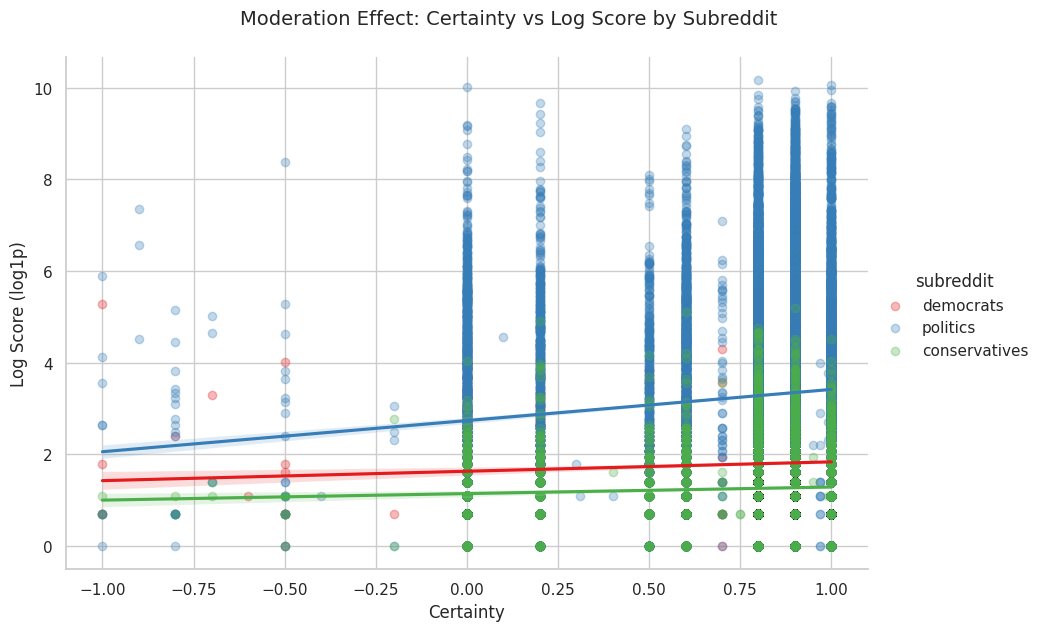

In [16]:
# Step 5: Visualization - lmplot
# Plotting the interaction effect of Certainty on Log Score by Subreddit
sns.set_theme(style="whitegrid")
g = sns.lmplot(
    data=df,
    x='certainty',
    y='log_score',
    hue='subreddit',
    height=6,
    aspect=1.5,
    palette='Set1',
    scatter_kws={'alpha': 0.3}
)

g.set_axis_labels("Certainty", "Log Score (log1p)")
g.fig.suptitle('Moderation Effect: Certainty vs Log Score by Subreddit', y=1.05, fontsize=14)
plt.show()


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Filter for Negative Events
neg_events_df = df[df['goal_congruence'] < 0].copy()

# Step 2: Agency Classification
def classify_agency(score):
    if score < -0.1:
        return 'Other-Agency/Blame'
    elif score > 0.1:
        return 'Self/Moral-Agency'
    else:
        return 'Circumstance-Agency'

neg_events_df['agency_category'] = neg_events_df['agency'].apply(classify_agency)

# Step 3: Keyword Extraction
print("Top 10 Keywords in Negative Events by Subreddit:")
for sub in ['conservatives', 'democrats', 'politics']:
    texts = neg_events_df[neg_events_df['subreddit'] == sub]['body'].fillna('')
    if len(texts) > 0:
        vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
        tfidf_matrix = vectorizer.fit_transform(texts)
        feature_names = vectorizer.get_feature_names_out()
        # Sum tf-idf scores for each word
        scores = tfidf_matrix.sum(axis=0).A1
        top_indices = scores.argsort()[::-1][:10]
        top_words = [feature_names[i] for i in top_indices]
        print(f"r/{sub}: {', '.join(top_words)}")


Top 10 Keywords in Negative Events by Subreddit:
r/conservatives: trump, just, people, like, don, gt, think, right, biden, know
r/democrats: trump, just, people, like, don, think, democrats, right, vote, reddit
r/politics: trump, people, just, like, don, think, right, gt, going, politics


In [21]:
# Step 4: Correlation Mapping for Specific Entities
entities = ['trump', 'biden','harris','clinton', 'democrats','epstein', 'republicans', 'media']
print("\nAverage Agency Score for Specific Entities (in Negative Events):")

entity_agency = []
for entity in entities:
    # Case-insensitive search for the entity
    mask = neg_events_df['body'].str.contains(entity, case=False, na=False)
    avg_agency = neg_events_df[mask]['agency'].mean()
    entity_agency.append({'Entity': entity.capitalize(), 'Avg Agency Score': avg_agency, 'Mentions': mask.sum()})

entity_df = pd.DataFrame(entity_agency)
display(entity_df)



Average Agency Score for Specific Entities (in Negative Events):


,Entity,Avg Agency Score,Mentions
0,Trump,0.075295,6533
1,Biden,0.118531,1171
2,Harris,0.099600,250
3,Clinton,0.069856,627
4,Democrats,0.048178,1509
5,Epstein,-0.028906,128
6,Republicans,0.034708,1818
7,Media,0.020000,1220


/tmp/ipykernel_12388/1060743965.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




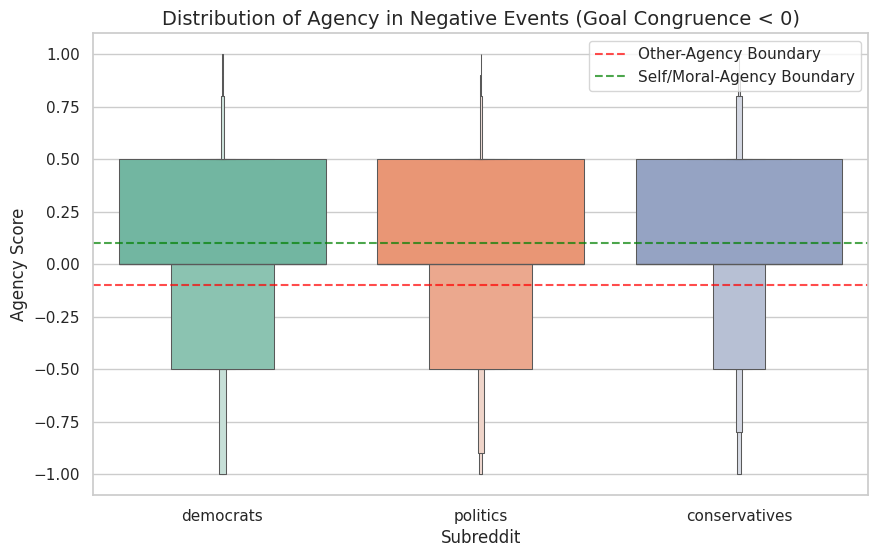


Interpretation Notes:
- Observe the median and interquartile ranges in the boxenplot.
- If a subreddit's distribution is heavily skewed below the red dashed line (-0.1), it indicates a strong 'Other-Agency/Blame' bias.
- If a subreddit's distribution is centered closer to 0 (between the dashed lines), it indicates more 'Circumstance-Agency' (less direct blame).


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 5: Visualization
plt.figure(figsize=(10, 6))
sns.boxenplot(data=neg_events_df, x='subreddit', y='agency', palette='Set2')
plt.title('Distribution of Agency in Negative Events (Goal Congruence < 0)', fontsize=14)
plt.ylabel('Agency Score', fontsize=12)
plt.xlabel('Subreddit', fontsize=12)

# Add horizontal lines for the classification boundaries
plt.axhline(y=-0.1, color='red', linestyle='--', alpha=0.7, label='Other-Agency Boundary')
plt.axhline(y=0.1, color='green', linestyle='--', alpha=0.7, label='Self/Moral-Agency Boundary')
plt.legend()
plt.show()

# Step 6: Interpretation
print("\nInterpretation Notes:")
print("- Observe the median and interquartile ranges in the boxenplot.")
print("- If a subreddit's distribution is heavily skewed below the red dashed line (-0.1), it indicates a strong 'Other-Agency/Blame' bias.")
print("- If a subreddit's distribution is centered closer to 0 (between the dashed lines), it indicates more 'Circumstance-Agency' (less direct blame).")


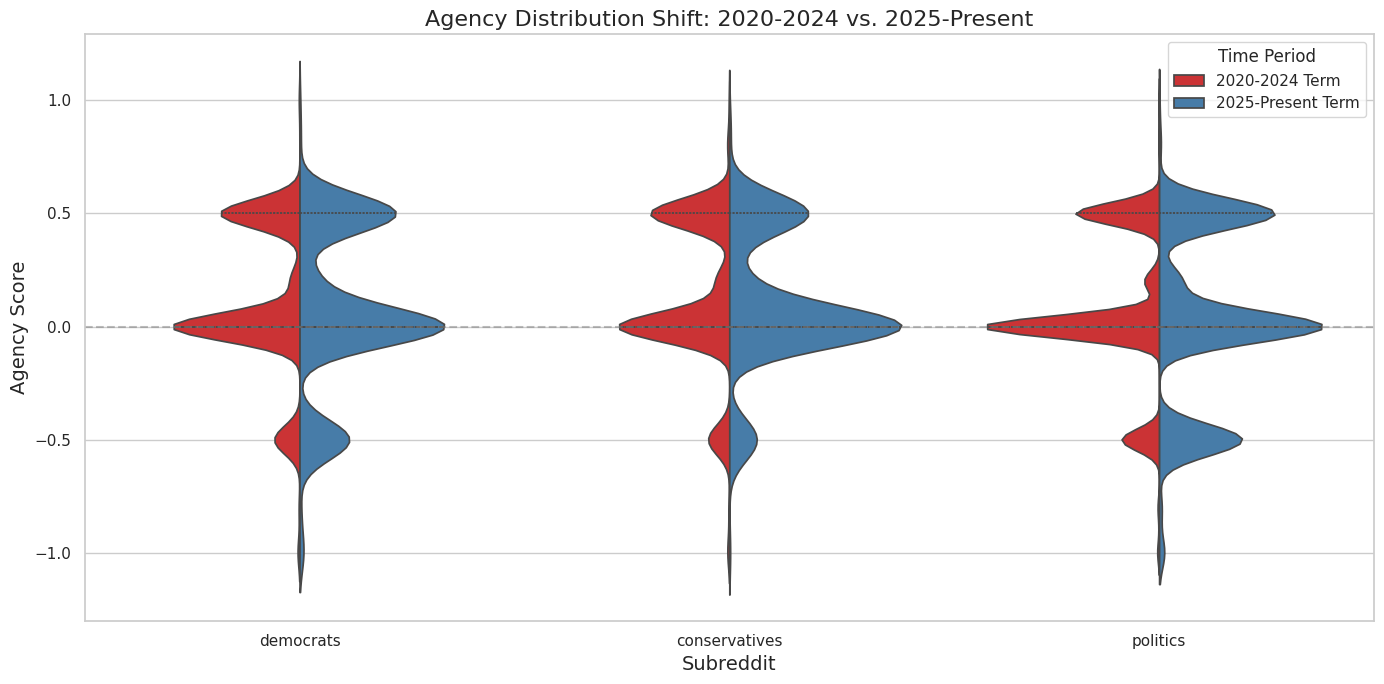

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Unix timestamp to datetime
df['datetime'] = pd.to_datetime(df['created_utc'], unit='s')

# Function to categorize by presidential term based on user specifications
def categorize_term(date):
    if pd.isna(date):
        return None
    if 2020 <= date.year <= 2024:
        return '2020-2024 Term'
    elif date.year >= 2025:
        return '2025-Present Term'
    else:
        return 'Pre-2020'

# Apply categorization
df['time_period'] = df['datetime'].apply(categorize_term)

# Filter for only the two relevant time periods
term_df = df[df['time_period'].isin(['2020-2024 Term', '2025-Present Term'])]

# Visualization: Split Violin Plot
plt.figure(figsize=(14, 7))
sns.violinplot(
    data=term_df,
    x='subreddit',
    y='agency',
    hue='time_period',
    split=True, # Splits the violin to show distributions side-by-side
    inner="quartile",
    palette="Set1"
)

plt.title('Agency Distribution Shift: 2020-2024 vs. 2025-Present', fontsize=16)
plt.xlabel('Subreddit', fontsize=14)
plt.ylabel('Agency Score', fontsize=14)
plt.legend(title='Time Period', loc='upper right')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5) # Reference line at 0
plt.tight_layout()
plt.show()
